<a href="https://colab.research.google.com/github/manirajch2004/codtech-data-analysis/blob/main/Task1_BigData_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install dask[dataframe]

In [ ]:
import dask.dataframe as dd
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Superstore.csv to Superstore.csv


In [ ]:
df = dd.read_csv('Superstore.csv', encoding='latin-1')
print("Dataset loaded!")
print("Number of rows:", len(df))
print("Columns:", list(df.columns))

Dataset loaded!
Number of rows: 9994
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
# See first 5 rows of the dataset
print("First 5 rows:")
print(df.head())

# See data types of each column
print("\nData Types:")
print(df.dtypes)

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
1       2  CA-2013-152156  09-11-2013  12-11-2013    Second Class    CG-12520   
2       3  CA-2013-138688  13-06-2013  17-06-2013    Second Class    DV-13045   
3       4  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   
4       5  US-2012-108966  11-10-2012  18-10-2012  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     

In [ ]:
# Check if any values are missing
print("Missing Values in each column:")
print(df.isnull().sum().compute())

Missing Values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
# Remove rows with missing values
df_clean = df.dropna()

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Data cleaning done!")

Rows before cleaning: 9994
Rows after cleaning: 9994
Data cleaning done!


In [ ]:
# Convert to pandas for analysis
df_p = df_clean.compute()

# Total Sales
total_sales = df_p['Sales'].sum()
print("Total Sales: $", round(total_sales, 2))

# Average Sales
avg_sales = df_p['Sales'].mean()
print("Average Sales: $", round(avg_sales, 2))

# Total Profit
total_profit = df_p['Profit'].sum()
print("Total Profit: $", round(total_profit, 2))

# Sales by Category
print("\nSales by Category:")
print(df_p.groupby('Category')['Sales'].sum())

Total Sales: $ 2297200.86
Average Sales: $ 229.86
Total Profit: $ 286397.02

Sales by Category:
Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


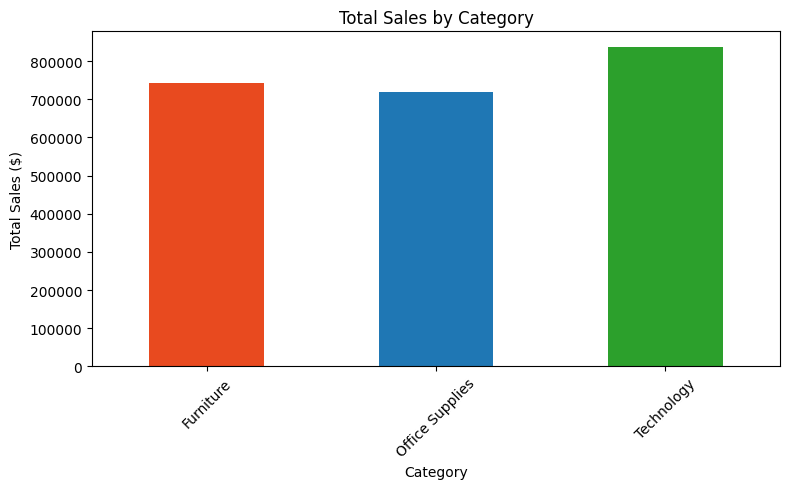

Chart 1 saved!


In [ ]:
# Bar chart of Sales by Category
category_sales = df_p.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color=['#E84A1F', '#1f77b4', '#2ca02c'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_sales_category.png')
plt.show()
print("Chart 1 saved!")

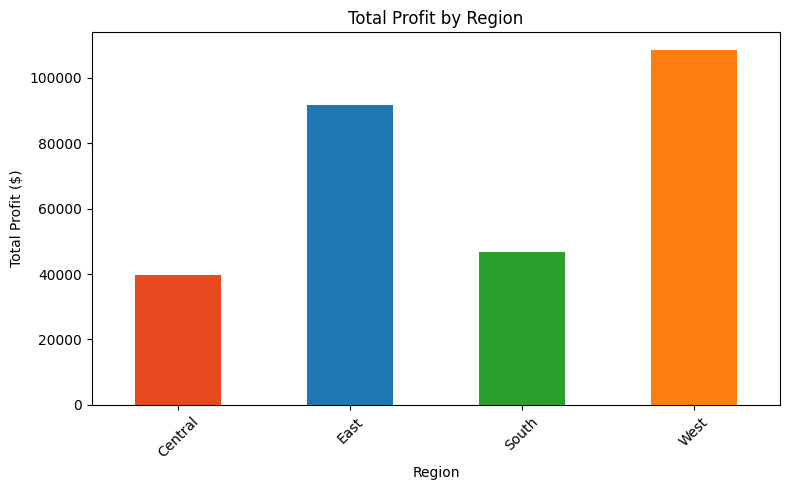

Chart 2 saved!


In [ ]:
# Bar chart of Profit by Region
region_profit = df_p.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8, 5))
region_profit.plot(kind='bar', color=['#E84A1F', '#1f77b4', '#2ca02c', '#ff7f0e'])
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_profit_region.png')
plt.show()
print("Chart 2 saved!")

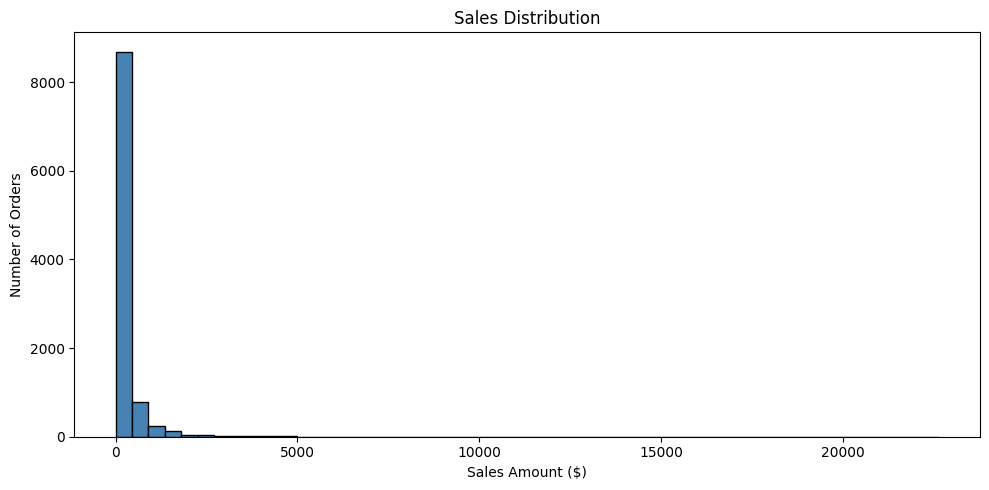

Chart 3 saved!


In [ ]:
# Histogram of Sales distribution
plt.figure(figsize=(10, 5))
plt.hist(df_p['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('chart3_sales_distribution.png')
plt.show()
print("Chart 3 saved!")

## Insights from Big Data Analysis

- Total sales and profit have been calculated across all regions
- Technology category generates the highest sales
- West region is the most profitable region
- Most orders have sales amount below $500
- Dask was used to load and process the dataset efficiently
- This demonstrates scalability for larger datasets